# Análisis de Logs

## 1. Carga del CSV

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('server_logs.csv')

df['timestamp_event'] = pd.to_datetime(df['timestamp_event'])

df.head()

,timestamp_event,received_at,service_name,severity,message,trace_id,request_id,method,endpoint,status_code,latency_ms,host,env,region,log_type
0,2026-01-10 00:02:39.029160+00:00,2026-01-10T00:02:39.097160Z,orders-service,INFO,Request completed,bd8e6ebe717b4c43ba5e72e1668641a8,e6b3009adcad,GET,/orders/create,200,99,orders-service-pod-03,prod,sa-east-1,request
1,2026-01-10 00:02:46.081021+00:00,2026-01-10T00:02:46.196021Z,api-gateway,INFO,Background job completed,40ac5ff97bae43d5b8045484725e0aca,e2aa1cccd1cf,GET,/health,200,122,api-gateway-pod-01,prod,sa-east-1,request
2,2026-01-10 00:04:01.648849+00:00,2026-01-10T00:04:01.718849Z,notification-service,WARN,Rate limit nearing threshold,c048b378759a4c54a6f7d7251a6acc88,c74106ca8581,POST,/notify/sms,200,646,notification-service-pod-03,prod,sa-east-1,request
3,2026-01-10 00:05:08.148346+00:00,2026-01-10T00:05:08.236346Z,api-gateway,INFO,Background job completed,072169f708c84227986bfda9f9657bdc,bf10fa3609bd,GET,/checkout,200,127,api-gateway-pod-03,prod,sa-east-1,request
4,2026-01-10 00:05:19.590837+00:00,2026-01-10T00:05:19.632837Z,inventory-service,INFO,Health check OK,e76a214131d24a4ea1acf389362e34cb,f672d669eda7,GET,/inv/release,200,144,inventory-service-pod-02,prod,sa-east-1,request


## 2. Exploración inicial

In [18]:
print('\nTotal de logs:', len(df))

print('\nConteo por severidad:')
print(df['severity'].value_counts())

# Contamos cuantos logs tiene cada servicio y ordenamos de mayor a menor
conteo_servicios = df['service_name'].value_counts()

print('\nServicio con MÁS logs:', conteo_servicios.index[0], '-', conteo_servicios.iloc[0])
print('\nServicio con MENOS logs:', conteo_servicios.index[-1], '-', conteo_servicios.iloc[-1])

print('\nMensaje más repetido:')
print(df['message'].value_counts().head(1))

# Definimos qué es un "bad event":
df['is_bad'] = (df['severity'].isin(['ERROR', 'CRITICAL'])) | (df['status_code'] >= 500)

# Filtramos solo los bad events
bad_events = df[df['is_bad'] == True]

print('\nMensaje malo más repetido:')
print(bad_events['message'].value_counts().head(1))


Total de logs: 5795

Conteo por severidad:
severity
INFO        3542
WARN        1358
ERROR        775
CRITICAL     120
Name: count, dtype: int64

Servicio con MÁS logs: api-gateway - 1509

Servicio con MENOS logs: notification-service - 645

Mensaje más repetido:
message
Health check OK    1196
Name: count, dtype: int64

Mensaje malo más repetido:
message
Order creation failed - inventory lock timeout    197
Name: count, dtype: int64


## 3. Detección del momento crítico

In [ ]:
df['window'] = df['timestamp_event'].dt.floor('5min')

ventanas = df.groupby('window').agg(
    total_events=('is_bad', 'count'),
    bad_events=('is_bad', 'sum')
).reset_index()

# Calculamos la tasa de eventos malos
ventanas['bad_rate'] = ventanas['bad_events'] / ventanas['total_events']

ventanas_filtradas = ventanas[ventanas['total_events'] >= 20]

# Ordenamos de peor a mejor y mostramos el top 5
top5 = ventanas_filtradas.sort_values('bad_rate', ascending=False).head(5)
top5 = top5.rename(columns={'window': 'window_start'})
print('\nTop 5 ventanas con mayor bad_rate:')
print(top5)

momento_critico = top5.iloc[0]['window_start']
print('\nMomento crítico:', momento_critico)


Top 5 ventanas con mayor bad_rate:
                 window_start  total_events  bad_events  bad_rate
134 2026-01-10 11:10:00+00:00           189         110  0.582011
135 2026-01-10 11:15:00+00:00           228         129  0.565789
136 2026-01-10 11:20:00+00:00           111          59  0.531532
462 2026-01-11 14:35:00+00:00           255         117  0.458824
461 2026-01-11 14:30:00+00:00           156          68  0.435897

Momento crítico: 2026-01-10 11:10:00+00:00


## 4. Diagnóstico dentro del momento crítico

In [ ]:
df_critico = df[df['window'] == momento_critico]

bad_critico = df_critico[df_critico['is_bad'] == True]

print('\nBad events por servicio durante el momento crítico:')
print(bad_critico['service_name'].value_counts())

print('\nTop 5 mensajes en bad events durante el momento crítico:')
print(bad_critico['message'].value_counts().head(5))

print('\nTop 5 endpoints con más bad events:')
print(bad_critico['endpoint'].value_counts().head(5))


Bad events por servicio durante el momento crítico:
service_name
orders-service       72
inventory-service    37
payment-service       1
Name: count, dtype: int64

Top 5 mensajes en bad events durante el momento crítico:
message
Order creation failed - inventory lock timeout    72
Database deadlock detected                        37
External dependency error                          1
Name: count, dtype: int64

Top 5 endpoints con más bad events:
endpoint
/orders/cancel    26
/orders/create    25
/orders/status    21
/inv/reserve      18
/inv/stock        13
Name: count, dtype: int64


## 5. Incidente vs Baseline

In [ ]:
df_baseline = df[df['window'] != momento_critico]

# Calculamos cada métrica 
br_inc   = df_critico['is_bad'].mean()
br_bas   = df_baseline['is_bad'].mean()
lat_inc  = df_critico['latency_ms'].mean()
lat_bas  = df_baseline['latency_ms'].mean()
p5xx_inc = (df_critico['status_code'] >= 500).mean() * 100
p5xx_bas = (df_baseline['status_code'] >= 500).mean() * 100

print('Comparación incidente vs baseline:')
print('total_events  incidente:', len(df_critico),  ' baseline:', len(df_baseline))
print('bad_rate      incidente:', round(br_inc, 4),  ' baseline:', round(br_bas, 4))
print('avg_latency   incidente:', round(lat_inc, 2), ' baseline:', round(lat_bas, 2))
print('%_5xx         incidente:', round(p5xx_inc, 2),' baseline:', round(p5xx_bas, 2))

Comparación incidente vs baseline:
total_events  incidente: 189  baseline: 5606
bad_rate      incidente: 0.582  baseline: 0.14
avg_latency   incidente: 1589.69  baseline: 521.09
%_5xx         incidente: 58.2  baseline: 14.0


## 6. Gráficos

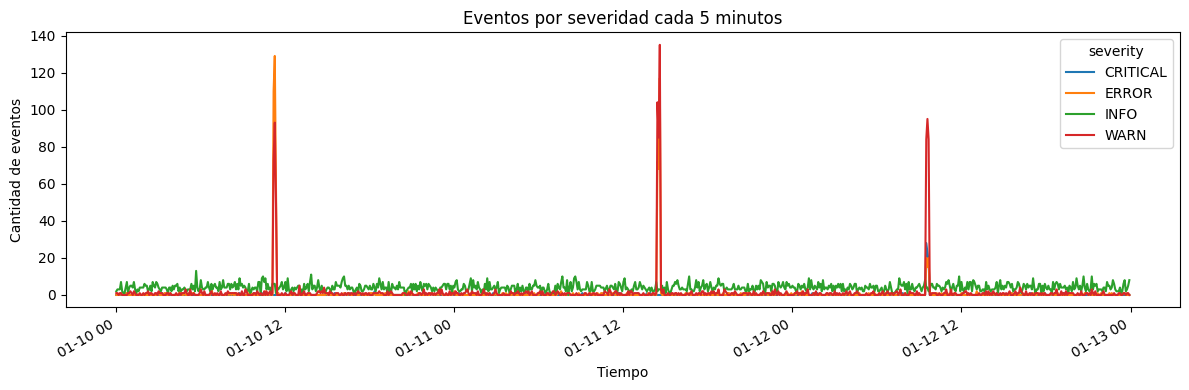

In [22]:
# GRÁFICO 1: Conteo de eventos por severidad en bins de 5 min 

# Agrupamos por ventana y severidad, contando cuántos eventos hay
grafico1 = df.groupby(['window', 'severity']).size().unstack(fill_value=0)

# Graficamos
grafico1.plot(figsize=(12, 4))
plt.title('Eventos por severidad cada 5 minutos')
plt.xlabel('Tiempo')
plt.ylabel('Cantidad de eventos')
plt.tight_layout()
plt.show()

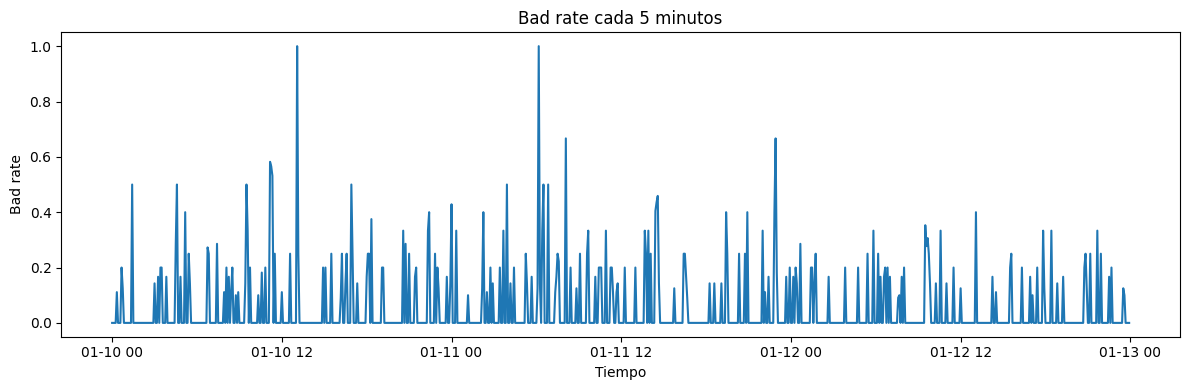

In [23]:
# GRÁFICO 2: bad_rate en bins de 5 min 

# Usamos la tabla de ventanas que ya calculamos antes
ventanas_ord = ventanas.sort_values('window')

# Graficamos
plt.figure(figsize=(12, 4))
plt.plot(ventanas_ord['window'], ventanas_ord['bad_rate'])
plt.title('Bad rate cada 5 minutos')
plt.xlabel('Tiempo')
plt.ylabel('Bad rate')
plt.tight_layout()
plt.show()

## 7. Conclusiones

In [24]:
conclusion = f"""
- Momento crítico:          {momento_critico}
- Servicio más afectado:    {bad_critico['service_name'].value_counts().index[0]}
- Endpoint más comprometido:{bad_critico['endpoint'].value_counts().index[0]}
- Mensaje dominante:        {bad_critico['message'].value_counts().index[0]}
- Comparación incidente vs baseline:
    bad_rate  incidente: {br_inc:.2%}  vs  bad_rate  baseline: {br_bas:.2%}
    latencia  incidente: {lat_inc:.2f} ms  vs  latencia  baseline: {lat_bas:.2f} ms
    %% 5xx    incidente: {p5xx_inc:.2f}%   vs  %% 5xx    baseline: {p5xx_bas:.2f}%
"""
print(conclusion)


- Momento crítico:          2026-01-10 11:10:00+00:00
- Servicio más afectado:    orders-service
- Endpoint más comprometido:/orders/cancel
- Mensaje dominante:        Order creation failed - inventory lock timeout
- Comparación incidente vs baseline:
    bad_rate  incidente: 58.20%  vs  bad_rate  baseline: 14.00%
    latencia  incidente: 1589.69 ms  vs  latencia  baseline: 521.09 ms
    %% 5xx    incidente: 58.20%   vs  %% 5xx    baseline: 14.00%

